Smoothing

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import data

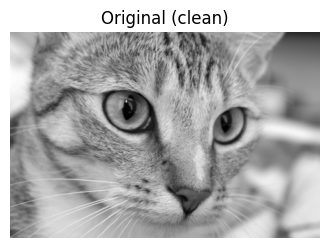

In [ ]:

img = data.cat() 
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')  
plt.title('Original (clean)')
plt.axis('off')
plt.show()

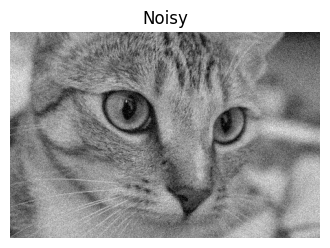

In [ ]:
def add_salt_and_pepper_noise(image, amount=0.05):

    noisy = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5)
    num_pepper = np.ceil(amount * image.size * 0.5)
   
    # Salt
    coords = [np.random.randint(0, i-1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 1

    # Pepper
    coords = [np.random.randint(0, i-1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy


def add_gaussian_noise(image, mean=0.0, sigma=0.05):

    image = image.astype(np.float32) / 255.0
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image + noise

    noisy = np.clip(noisy, 0, 1) * 255
    return noisy.astype(np.uint8) 


# Salt-and-Pepper
# noisy_img = add_salt_and_pepper_noise(img, amount=0.05)

# Gaussian-Noise 
noisy_img = add_gaussian_noise(img, sigma=0.05)


plt.figure(figsize=(4,4))
plt.imshow(noisy_img, cmap='gray') 
plt.title('Noisy')
plt.axis('off')
plt.show()

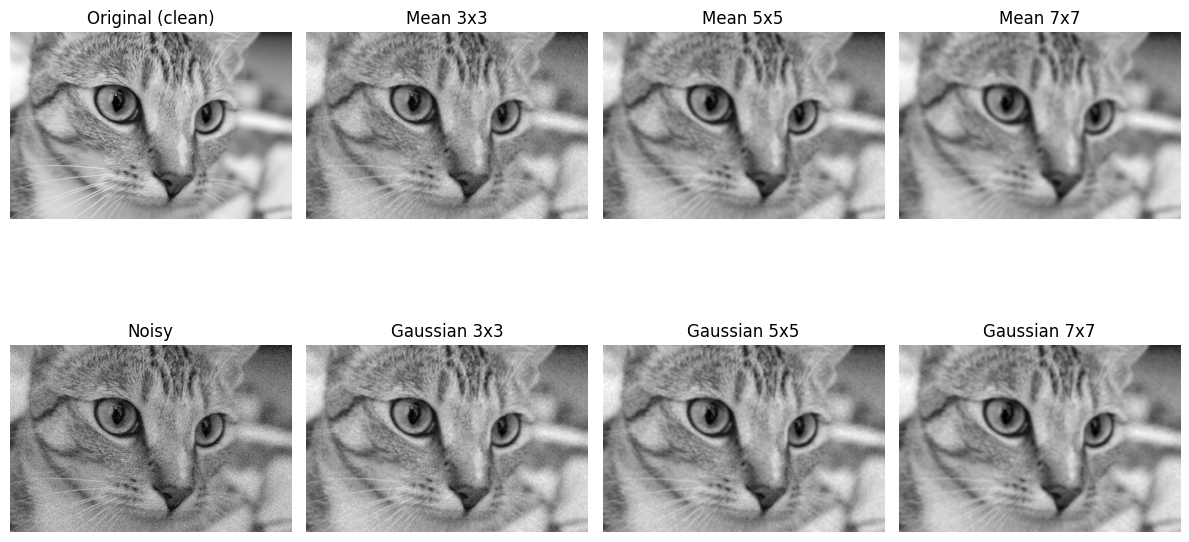

In [ ]:
# Linear filter: mean & Gaussian

kernels = [3, 5, 7]  

plt.figure(figsize=(12, 10))

# mean/box filter
plt.subplot(3, len(kernels) + 1, 1)
plt.imshow(img, cmap='gray')
plt.title("Original (clean)")
plt.axis("off")
for col, k in enumerate(kernels):
    mean_filtered = cv2.blur(noisy_img, (k, k))
    plt.subplot(3, len(kernels) + 1, col + 2) 
    plt.imshow(mean_filtered, cmap='gray')
    plt.title(f"Mean {k}x{k}")
    plt.axis("off")

# Gaussian filter
plt.subplot(3, len(kernels) + 1, (len(kernels) + 1) * 1 + 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
for col, k in enumerate(kernels):
    gauss_filtered = cv2.GaussianBlur(noisy_img, (k, k), 0)
    plt.subplot(3, len(kernels) + 1, (len(kernels) + 1) * 1 + (col + 2))
    plt.imshow(gauss_filtered, cmap='gray')
    plt.title(f"Gaussian {k}x{k}")
    plt.axis("off")

plt.tight_layout()
plt.show()


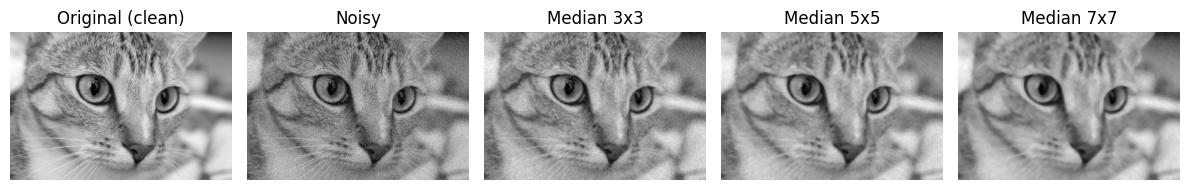

In [ ]:
# Edge-preserving smoother: median filter

kernels = [3, 5, 7]  

plt.figure(figsize=(12, 8))
num_cols = 2 + len(kernels)  

plt.subplot(1, num_cols, 1)
plt.imshow(img, cmap='gray')
plt.title('Original (clean)')
plt.axis('off')

plt.subplot(1, num_cols, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy')
plt.axis('off')

for col, k in enumerate(kernels):
    median_filtered = cv2.medianBlur(noisy_img, k)
    plt.subplot(1, num_cols, col + 3)
    plt.imshow(median_filtered, cmap='gray')
    plt.title(f'Median {k}x{k}')
    plt.axis('off')

plt.tight_layout()
plt.show()
